In [8]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [9]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [10]:
def create_model():
  model = Sequential([
      Dense(128, activation='relu', input_shape=(784,)),
      Dense(64, activation='relu'),
      Dense(10, activation='softmax')
  ])
  return model

Train with fixed learning rate

In [12]:
model_fixed = create_model()
model_fixed.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Reshape X_train and X_test for the Dense layers
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

history_fixed = model_fixed.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9179 - loss: 0.2771 - val_accuracy: 0.9569 - val_loss: 0.1487
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9643 - loss: 0.1165 - val_accuracy: 0.9683 - val_loss: 0.1046
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9741 - loss: 0.0815 - val_accuracy: 0.9709 - val_loss: 0.0951
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9816 - loss: 0.0595 - val_accuracy: 0.9707 - val_loss: 0.0971
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9852 - loss: 0.0469 - val_accuracy: 0.9719 - val_loss: 0.1005
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9886 - loss: 0.0379 - val_accuracy: 0.9759 - val_loss: 0.0887
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9903 - loss: 0.0298 - val_accuracy: 0.9737 - val_loss: 0.1020
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9921 - loss: 0.0246 - 

In [13]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,     # reduce LR by 50%
    patience=2,
    min_lr=1e-5
)

model_lr = create_model()

model_lr.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_lr = model_lr.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[lr_scheduler],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9223 - loss: 0.2658 - val_accuracy: 0.9567 - val_loss: 0.1429 - learning_rate: 0.0010
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9659 - loss: 0.1129 - val_accuracy: 0.9663 - val_loss: 0.1089 - learning_rate: 0.0010
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9757 - loss: 0.0757 - val_accuracy: 0.9693 - val_loss: 0.1029 - learning_rate: 0.0010
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9812 - loss: 0.0587 - val_accuracy: 0.9735 - val_loss: 0.0894 - learning_rate: 0.0010
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9853 - loss: 0.0455 - val_accuracy: 0.9730 - val_loss: 0.0968 - learning_rate: 0.0010
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9881 - loss: 0.0366 - val_accuracy: 0.9743 - val_loss: 0.0965 - learning_rate: 0.0010
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9952 - l

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model_es = create_model()

model_es.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_es = model_es.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9225 - loss: 0.2658 - val_accuracy: 0.9609 - val_loss: 0.1363
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9648 - loss: 0.1146 - val_accuracy: 0.9670 - val_loss: 0.1122
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9763 - loss: 0.0777 - val_accuracy: 0.9613 - val_loss: 0.1312
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9819 - loss: 0.0588 - val_accuracy: 0.9744 - val_loss: 0.0870
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9853 - loss: 0.0449 - val_accuracy: 0.9732 - val_loss: 0.0922
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9876 - loss: 0.0364 - val_accuracy: 0.9773 - val_loss: 0.0873
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9904 - loss: 0.0296 - val_accuracy: 0.9717 - val_loss: 0.1091


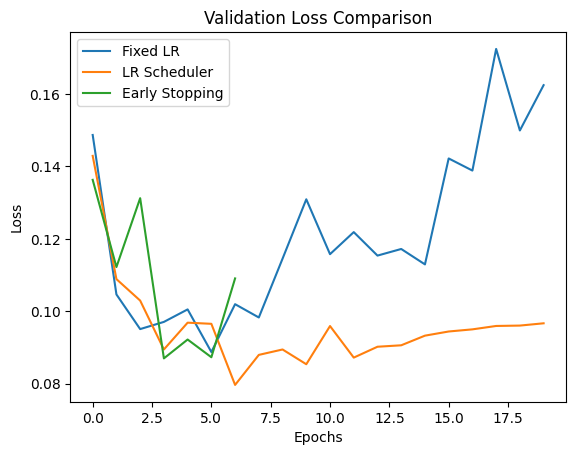

In [15]:
plt.plot(history_fixed.history['val_loss'], label='Fixed LR')
plt.plot(history_lr.history['val_loss'], label='LR Scheduler')
plt.plot(history_es.history['val_loss'], label='Early Stopping')
plt.legend()
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [16]:
print("Fixed LR epochs:", len(history_fixed.history['loss']))
print("LR Scheduler epochs:", len(history_lr.history['loss']))
print("Early Stopping epochs:", len(history_es.history['loss']))

Fixed LR epochs: 20
LR Scheduler epochs: 20
Early Stopping epochs: 7
